In [ ]:
import pandas as pd
from scipy.sparse import hstack, csr_matrix
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import classification_report
from sentence_transformers import SentenceTransformer
from catboost import CatBoostClassifier
import matplotlib.pyplot as plt
import pickle

In [8]:
data = pd.read_csv('../data/dataset_massive.csv')
data.head()

,Unnamed: 0,published_utc,title,description,publisher,ticker,sentiment
0,0,2026-06-03T20:26:39Z,The 'VOO And Chill' Economy Is Now Worth A His...,Vanguard's S&P 500 ETF (VOO) has become the fi...,Benzinga,AAPL,positive
1,1,2026-06-03T20:26:39Z,The 'VOO And Chill' Economy Is Now Worth A His...,Vanguard's S&P 500 ETF (VOO) has become the fi...,Benzinga,MSFT,positive
2,2,2026-06-03T20:26:39Z,The 'VOO And Chill' Economy Is Now Worth A His...,Vanguard's S&P 500 ETF (VOO) has become the fi...,Benzinga,NVDA,positive
3,3,2026-06-03T19:22:01Z,Broadcom's AI Revenue Doubled — And It May Not...,Broadcom reported $8.4 billion in AI semicondu...,Benzinga,META,positive
4,4,2026-06-03T19:22:01Z,Broadcom's AI Revenue Doubled — And It May Not...,Broadcom reported $8.4 billion in AI semicondu...,Benzinga,AAPL,positive


In [10]:
data_preprocessed = data.copy()

company_names = {"AAPL": "Apple", "MSFT": "Microsoft", "GOOGL": "Google", "META": "Meta", "AMZN": "Amazon", "NVDA": "Nvidia", "NFLX": "Netflix", 
                 "ADBE": "Adobe", "INTC": "Intel", "AMD": "AMD", "IBM": "IBM", "CSCO": "Cisco"}
data_preprocessed["company_name"] = data_preprocessed["ticker"].map(company_names)
data_preprocessed['text'] = (data_preprocessed["title"] + ". " + data_preprocessed["description"])
data_preprocessed['target'] = data_preprocessed['sentiment'].map({'negative': -1, 'neutral': 0, 'positive': 1})
data_preprocessed["datetime"] = pd.to_datetime(data_preprocessed["published_utc"], format="%Y-%m-%dT%H:%M:%SZ", errors="coerce", utc=True)
data_preprocessed["article_id"] = (data_preprocessed["datetime"].astype(str) + "_" + data_preprocessed["title"] + "_" + data_preprocessed["publisher"]).factorize()[0]
data_preprocessed = data_preprocessed.dropna()

In [13]:
X = data_preprocessed['text']
y = data_preprocessed["target"]
groups = data_preprocessed["article_id"]

splitter = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
train_idx, test_idx = next(splitter.split(X, y, groups=groups))

train = data_preprocessed.iloc[train_idx].copy()
test = data_preprocessed.iloc[test_idx].copy()

X_train = train['text']
X_test = test['text']
y_train = train['target']
y_test = test['target']

sent_transformer = SentenceTransformer("mukaj/fin-mpnet-base")
X_train_sentran_text = sent_transformer.encode(X_train.astype(str).tolist(), batch_size=32, show_progress_bar=True, convert_to_numpy=True)
X_test_sentran_text = sent_transformer.encode(X_test.astype(str).tolist(), batch_size=32, show_progress_bar=True, convert_to_numpy=True)

ohe_company = OneHotEncoder(handle_unknown="ignore")
X_train_company = ohe_company.fit_transform(train[["company_name"]])
X_test_company = ohe_company.transform(test[["company_name"]])

X_train_sentran_stacked = hstack([csr_matrix(X_train_sentran_text), X_train_company])
X_test_sentran_stacked = hstack([csr_matrix(X_test_sentran_text), X_test_company])

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/373 [00:00<?, ?it/s]

Batches:   0%|          | 0/97 [00:00<?, ?it/s]

In [24]:
best_params_catboost = {'iterations': 534, 
                        'learning_rate': 0.08842459522869721, 
                        'depth': 7, 'l2_leaf_reg': 9.371485582972626, 
                        'bagging_temperature': 1.4509350729845583, 
                        'auto_class_weights': 'SqrtBalanced',
                        "loss_function": "MultiClass",
                        "eval_metric": "TotalF1:average=Macro",
                        "random_seed": 42,
                        "task_type": "CPU",
                        "verbose": 0}

best_catboost = CatBoostClassifier(**best_params_catboost)
best_catboost.fit(X_train_sentran_stacked, y_train, eval_set=(X_test_sentran_stacked, y_test), verbose=0, plot=False)

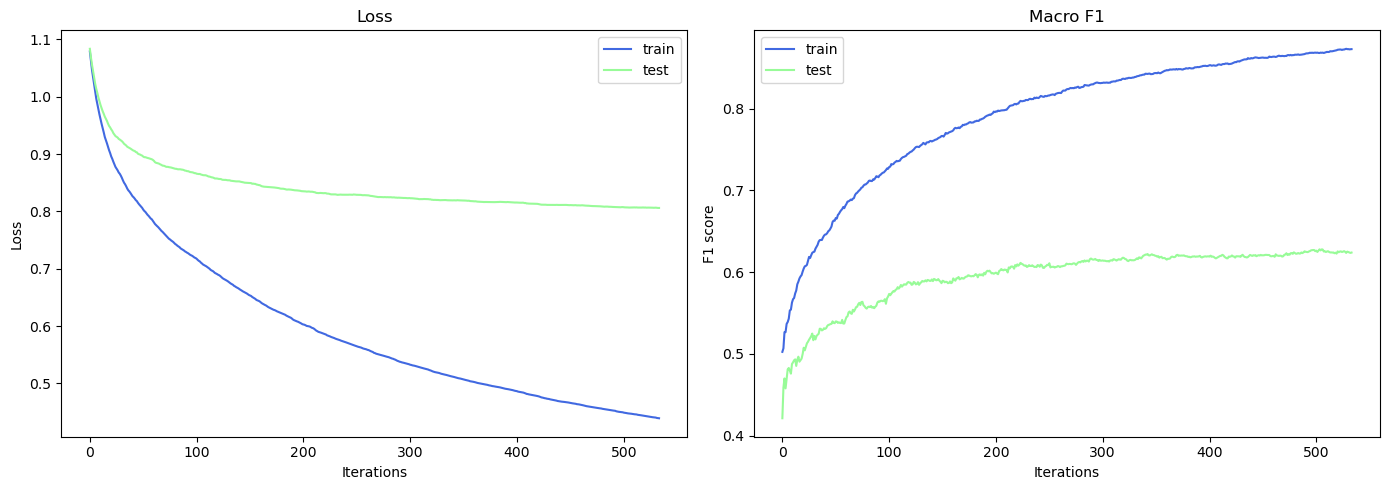

In [25]:
results = best_catboost.get_evals_result()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(results['learn']['MultiClass'], label='train', color='royalblue')
axes[0].plot(results['validation']['MultiClass'], label='test', color='palegreen')
axes[0].set_title('Loss')
axes[0].set_xlabel('Iterations')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(results['learn']['TotalF1:average=Macro'], label='train', color='royalblue')
axes[1].plot(results['validation']['TotalF1:average=Macro'], label='test', color='palegreen')
axes[1].set_title('Macro F1')
axes[1].set_xlabel('Iterations')
axes[1].set_ylabel('F1 score')
axes[1].legend()

plt.tight_layout()
plt.show()


In [20]:
pred_test = best_catboost.predict(X_test_sentran_stacked)

print(classification_report(y_test, pred_test))

              precision    recall  f1-score   support

        -1.0       0.52      0.52      0.52       296
         0.0       0.61      0.61      0.61      1187
         1.0       0.72      0.72      0.72      1611

    accuracy                           0.66      3094
   macro avg       0.62      0.62      0.62      3094
weighted avg       0.66      0.66      0.66      3094



In [43]:
with open("models/model_ohe.pkl", "wb") as f:
    pickle.dump(ohe_company, f)

sent_transformer.save("models/model_sbert")

best_catboost.save_model("models/model_classification.cbm")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]